<a href="https://colab.research.google.com/github/fabianorc2506-sys/Fundamentos_em_Ciencias_de_Dados/blob/Aulas/Aula_2_Adriano_Sele%C3%A7%C3%A3o_de_Vari%C3%A1veis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seleção de Variáveis em Modelo Mistos

## Teoria da Seleção Stepwise de Variáveis

A seleção de variáveis é uma etapa crucial na construção de modelos preditivos e explicativos. O objetivo é identificar o subconjunto de variáveis independentes (preditoras) que melhor explica a variável dependente (resposta), minimizando a complexidade do modelo e evitando problemas como overfitting. Uma das técnicas mais populares para isso é a **seleção stepwise** (passo a passo).

### O que é a Seleção Stepwise?

A seleção stepwise é um método iterativo e guloso (*greedy*) que adiciona ou remove variáveis de um modelo estatístico (geralmente regressão linear ou logística) uma por uma, com base em um critério de desempenho predefinido. O processo continua até que nenhuma variável possa ser adicionada ou removida para melhorar o modelo de forma significativa de acordo com o critério escolhido.

### Tipos de Seleção Stepwise

Existem três abordagens principais:

1. **Forward Selection (Seleção Progressiva ou Para Frente):**
   * Começa com um modelo vazio (apenas o intercepto).
   * Em cada etapa, adiciona a variável que mais melhora o modelo (de acordo com o critério escolhido, como AIC, BIC, p-valor ou R² ajustado).
   * Para quando nenhuma variável restante produz melhoria estatisticamente significativa.

2. **Backward Elimination (Eliminação Regressiva ou Para Trás):**
   * Começa com um modelo contendo **todas** as variáveis preditoras disponíveis.
   * Em cada etapa, remove a variável que menos contribui para o modelo (aquela cuja remoção menos prejudica o critério).
   * Para quando a remoção de qualquer variável restante piora significativamente o modelo.

3. **Bidirectional (Stepwise Misto ou Eliminação/Adição Bidirecional):**
   * Combina os dois métodos anteriores.
   * Pode tanto adicionar quanto remover variáveis em cada etapa.
   * Geralmente considerado o mais flexível e robusto dos três, pois permite corrigir decisões anteriores (remover variáveis que se tornaram redundantes após a inclusão de outras).

### Critérios de Seleção

Os métodos stepwise utilizam critérios estatísticos para decidir quais variáveis adicionar ou remover:

* **AIC (Akaike Information Criterion):** Penaliza a complexidade do modelo. Busca o modelo com menor AIC.
* **BIC (Bayesian Information Criterion):** Impõe penalidade maior que o AIC para modelos complexos, favorecendo soluções mais parcimoniosas.
* **p-valor:** Critério mais clássico. Define-se um `p-enter` (ex.: 0.05) para inclusão e um `p-remove` (ex.: 0.10) para exclusão.
* **R² Ajustado:** Leva em conta o número de preditores, penalizando a adição de variáveis que não melhoram suficientemente o ajuste.

> **Nota:** É comum combinar critérios (ex.: usar p-valor para entrada/saída e AIC/BIC para comparação final).

### Vantagens e Desvantagens

**Vantagens:**
- Automatiza a seleção em conjuntos de dados com muitas variáveis.
- Rápida e fácil de implementar.
- Útil como ferramenta exploratória.

**Desvantagens:**
- **Risco de overfitting** se não for validada adequadamente (ex.: validação cruzada).
- **Dependência da ordem** das variáveis (métodos gulosos podem chegar a soluções subótimas).
- **Não garante o melhor modelo global** — apenas um bom modelo local.
- Pode ser instável na presença de **multicolinearidade** forte.
- Ignora conhecimento de domínio do pesquisador.

### Quando Usar (e Quando Ter Cuidado)

A seleção stepwise é útil como **ferramenta exploratória** ou quando se tem um número muito grande de variáveis.  
**Recomenda-se fortemente**:
- Combinar com conhecimento de domínio.
- Usar validação cruzada ou bootstrapping para avaliar o modelo final.
- Preferir métodos mais modernos (LASSO, Ridge, Elastic Net, Recursive Feature Elimination com validação cruzada, etc.) quando possível.

**Em resumo**, a seleção stepwise é uma técnica prática e intuitiva para a exploração inicial de variáveis, mas deve ser usada com cautela e nunca como única estratégia de seleção de modelo.

## Exemplo Prático: Seleção de Variáveis em Modelos de Efeitos Mistos com Dados Ames Housing

Nesta seção, demonstraremos como realizar a seleção de variáveis para os efeitos fixos em um Modelo Linear de Efeitos Mistos (LMM). Para isso, utilizaremos o conjunto de dados **Ames Housing**, que contém informações de vendas de imóveis residenciais em Ames, Iowa.

Os dados são organizados em dois níveis: **imóveis** (nível 1 — 2930 casas) agrupados dentro de **bairros** (nível 2 — 28 bairros). Essa estrutura hierárquica permite modelar simultaneamente os efeitos fixos das características dos imóveis e os efeitos aleatórios que capturam a variabilidade de preço base entre os diferentes bairros.

Partindo de um modelo inicial contendo todos os preditores candidatos, aplicaremos procedimentos de **seleção Stepwise** (Forward, Backward e Bidirecional) para identificar um conjunto mais parcimonioso de variáveis para os efeitos fixos. A comparação entre os modelos será realizada por meio dos critérios de informação **AIC** e **BIC**.

**Variável resposta**: `log(SalePrice)` - o logaritmo do preço de venda, que apresenta distribuição aproximadamente normal.

**Efeito aleatório de intercepto**: `(1|Neighborhood)` - cada bairro possui seu próprio intercepto base.

**Preditores candidatos**: `Gr_Liv_Area`, `Year_Built`, `Overall_Qual`, `Garage_Cars`, `Total_Bsmt_SF`, `Full_Bath`, `Lot_Area`, entre outros.

### 1. Descrição do Dataset Real: `Ames Housing`

O dataset **Ames Housing** é um conjunto de dados imobiliários **reais** coletados pela prefeitura de Ames, Iowa. O estudo registrou características físicas e de localização de imóveis residenciais vendidos entre 2006 e 2010.

Foram amostradas 2930 casas distribuídas em 28 bairros, com número variável de observações por bairro. O objetivo principal era entender como fatores estruturais e locacionais influenciam o preço de venda.

**Principais Variáveis:**

* `SalePrice`: Variável resposta contínua — Preço de venda do imóvel em dólares. Usaremos `log(SalePrice)` para garantir normalidade.
* `Gr_Liv_Area`: Área construída acima do solo (pés²) — principal preditor contínuo.
* `Year_Built`: Ano de construção do imóvel.
* `Overall_Qual`: Qualidade geral de acabamento e materiais, escala 1-10.
* `Garage_Cars`: Capacidade da garagem em número de carros.
* `Total_Bsmt_SF`: Área total do porão (pés²).
* `Full_Bath`: Número de banheiros completos.
* `Lot_Area`: Área do terreno (pés²).
* `Neighborhood`: ID do bairro (variável de agrupamento — nível 2).

**Por que é adequado para Modelos de Efeitos Mistos?**  
As observações apresentam uma clara estrutura hierárquica: imóveis (nível 1) aninhados dentro de bairros (nível 2). Casas pertencentes ao mesmo bairro compartilham condições locacionais semelhantes (proximidade de escolas, segurança, infraestrutura, etc.), gerando correlação intra-bairro. Um **Modelo Linear de Efeitos Mistos (LMM)** permite estimar os efeitos fixos das características dos imóveis (como `Gr_Liv_Area` e `Overall_Qual`) enquanto captura a variabilidade aleatória entre os diferentes bairros através de um intercepto aleatório por `Neighborhood`.

### 2. Pipeline de Dados: Carregamento e Pré-processamento

In [ ]:
import pandas as pd
import numpy as np

# ====================== DATA LOADING FROM URL ======================
# URL pública com o dataset Ames Housing completo
url_ames = "https://github.com/user-attachments/files/21813529/ames_housing_no_missing.csv"

try:
    df_final = pd.read_csv(url_ames)
    print(f"✅ Ames Housing dataset carregado com sucesso da URL")
except Exception as e:
    print(f"❌ Falha ao carregar o dataset Ames Housing. Erro: {e}")
    raise SystemExit("Não foi possível carregar o dataset Ames Housing.")

# ====================== DATA CLEANING & FEATURE ENGINEERING ======================
# Criar log da variável resposta para garantir normalidade
if 'SalePrice' in df_final.columns:
    df_final['log_saleprice'] = np.log(df_final['SalePrice'])
    print("Criada variável 'log_saleprice' = log(SalePrice)")

# Padronizar nomes: remover espaços, deixar lowercase
df_final.columns = df_final.columns.str.replace(' ', '_').str.lower()

# Tratar NA básicos nas covariáveis que vamos usar
cols_numericas = ['gr_liv_area', 'year_built', 'overall_qual', 'garage_cars',
                  'total_bsmt_sf', 'full_bath', 'lot_area']
for col in cols_numericas:
    # Acessa as colunas com os nomes padronizados
    if col.replace('_', '') in df_final.columns: # Check for the name without underscore
        df_final[col.replace('_', '')] = df_final[col.replace('_', '')].fillna(df_final[col.replace('_', '')].median())

print(df_final.shape)
print(df_final.columns.tolist())

print("\n=== DATASET AMES HOUSING CARREGADO E PRÉ-PROCESSADO ===")
print(f"Total de imóveis: {df_final.shape[0]}")

# Check if 'neighborhood' column exists before trying to get unique count
if 'neighborhood' in df_final.columns:
    print(f"Total de bairros: {df_final['neighborhood'].nunique()}")
    print(f"Distribuição por bairro:\n{df_final['neighborhood'].value_counts().head()}")
else:
    print("Warning: 'neighborhood' column not found in df_final.")

print(f"\nColunas disponíveis: {list(df_final.columns)}")
display(df_final.head())

# ====================== DEFINIÇÃO DE VARIÁVEIS ======================
resposta = 'log_saleprice' # Usando log para normalidade
grupo = 'neighborhood' # Nível 2: agrupamento

# Preditores que realmente existem no dataset carregado após padronização
# Use os nomes exatos após a padronização (lowercase e sem underscores)
preditores_totais = [col for col in ['grlivarea', 'yearbuilt', 'overallqual', 'garagecars',
                                     'totalbsmtsf', 'fullbath', 'lotarea']
                     if col in df_final.columns]

print(f"\nVariável resposta: '{resposta}'")
print(f"Agrupamento (nível 2): '{grupo}'")
print(f"Preditores disponíveis: {preditores_totais}")

# Remove linhas com NA na resposta ou no grupo
df_final = df_final.dropna(subset=[resposta, grupo])
print(f"\nDataset final após remover NAs: {df_final.shape[0]} observações")

✅ Ames Housing dataset carregado com sucesso da URL
Criada variável 'log_saleprice' = log(SalePrice)
(1460, 81)
['mssubclass', 'mszoning', 'lotfrontage', 'lotarea', 'street', 'alley', 'lotshape', 'landcontour', 'utilities', 'lotconfig', 'landslope', 'neighborhood', 'condition1', 'condition2', 'bldgtype', 'housestyle', 'overallqual', 'overallcond', 'yearbuilt', 'yearremodadd', 'roofstyle', 'roofmatl', 'exterior1st', 'exterior2nd', 'masvnrtype', 'masvnrarea', 'exterqual', 'extercond', 'foundation', 'bsmtqual', 'bsmtcond', 'bsmtexposure', 'bsmtfintype1', 'bsmtfinsf1', 'bsmtfintype2', 'bsmtfinsf2', 'bsmtunfsf', 'totalbsmtsf', 'heating', 'heatingqc', 'centralair', 'electrical', '1stflrsf', '2ndflrsf', 'lowqualfinsf', 'grlivarea', 'bsmtfullbath', 'bsmthalfbath', 'fullbath', 'halfbath', 'bedroomabvgr', 'kitchenabvgr', 'kitchenqual', 'totrmsabvgrd', 'functional', 'fireplaces', 'fireplacequ', 'garagetype', 'garageyrblt', 'garagefinish', 'garagecars', 'garagearea', 'garagequal', 'garagecond', 'p

,mssubclass,mszoning,lotfrontage,lotarea,street,alley,lotshape,landcontour,utilities,lotconfig,...,poolqc,fence,miscfeature,miscval,mosold,yrsold,saletype,salecondition,saleprice,log_saleprice
0,60,RL,65.0,8450,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,Gd,MnPrv,Shed,0,2,2008,WD,Normal,208500,12.247694
1,20,RL,80.0,9600,Pave,Grvl,Reg,Lvl,AllPub,FR2,...,Gd,MnPrv,Shed,0,5,2007,WD,Normal,181500,12.109011
2,60,RL,68.0,11250,Pave,Grvl,IR1,Lvl,AllPub,Inside,...,Gd,MnPrv,Shed,0,9,2008,WD,Normal,223500,12.317167
3,70,RL,60.0,9550,Pave,Grvl,IR1,Lvl,AllPub,Corner,...,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml,140000,11.849398
4,60,RL,84.0,14260,Pave,Grvl,IR1,Lvl,AllPub,FR2,...,Gd,MnPrv,Shed,0,12,2008,WD,Normal,250000,12.429216



Variável resposta: 'log_saleprice'
Agrupamento (nível 2): 'neighborhood'
Preditores disponíveis: ['grlivarea', 'yearbuilt', 'overallqual', 'garagecars', 'totalbsmtsf', 'fullbath', 'lotarea']

Dataset final após remover NAs: 1460 observações


### 3. Justificativa para a Inclusão de Efeitos Aleatórios

Antes de realizar a seleção de variáveis dos efeitos fixos, é necessário verificar se a estrutura hierárquica dos dados justifica a utilização de um Modelo Linear de Efeitos Mistos (LMM). Como os imóveis (nível 1) estão agrupados dentro de bairros (nível 2), é plausível supor que casas pertencentes ao mesmo bairro apresentem maior similaridade de preço entre si do que em relação a imóveis de outros bairros.

Nesta seção, compararemos um modelo de regressão linear tradicional (OLS) com um modelo misto contendo intercepto aleatório para os bairros (`Neighborhood`). A comparação será realizada por meio de critérios de ajuste, como AIC e BIC, além da avaliação da variabilidade associada ao efeito aleatório (variância entre bairros). Caso a inclusão da estrutura multinível produza melhora substancial no ajuste, teremos evidências favoráveis à utilização do modelo misto nas etapas subsequentes.

In [ ]:
# ==========================================================
# 3. Justificativa para a Inclusão de Efeitos Aleatórios
# ==========================================================
#
# Objetivo:
# Verificar se há variabilidade significativa entre bairros (Neighborhood)
# que justifique o uso de um Modelo Linear de Efeitos Mistos (LMM).
#
# Estratégia:
# 1. Ajustar modelo nulo (sem preditores)
# 2. Estimar ICC (correlação intra-bairro)
# 3. Comparar OLS vs LMM (com subconjunto relevante de variáveis)
# ==========================================================

import statsmodels.formula.api as smf
# 'resposta', 'grupo', 'df_final' e 'preditores_totais' vêm da célula anterior

# ----------------------------------------------------------
# 1. MODELO NULO (apenas intercepto + efeito aleatório por Neighborhood)
# ----------------------------------------------------------
modelo_nulo = smf.mixedlm(
    f"{resposta} ~ 1",
    data=df_final,
    groups=df_final[grupo]
).fit(reml=True)

# Variâncias do modelo nulo
var_bairro = modelo_nulo.cov_re.iloc[0, 0]
var_residual = modelo_nulo.scale

# ICC (Intraclass Correlation Coefficient)
icc = var_bairro / (var_bairro + var_residual)

print("=== MODELO NULO ===")
print(f"Variância entre bairros (Nível 2): {var_bairro:.6f}")
print(f"Variância residual (Nível 1): {var_residual:.6f}")
print(f"ICC: {icc:.4f} = {icc*100:.1f}% da variância total vem do bairro")

# Usaremos as principais variáveis dos imóveis para esta comparação inicial.
# A seleção stepwise posterior será mais abrangente.
if preditores_totais:
    comparacao_preditores = " + ".join(preditores_totais)
else:
    comparacao_preditores = "1" # Para um modelo apenas com intercepto

# ----------------------------------------------------------
# 2. MODELO OLS (sem estrutura hierárquica)
# ----------------------------------------------------------
modelo_ols = smf.ols(
    f"{resposta} ~ {comparacao_preditores}",
    data=df_final
).fit()

# ----------------------------------------------------------
# 3. MODELO LMM (intercepto aleatório por bairro)
# ----------------------------------------------------------
modelo_lmm = smf.mixedlm(
    f"{resposta} ~ {comparacao_preditores}",
    data=df_final,
    groups=df_final[grupo]
).fit(reml=False) # ML para comparar com OLS

# ----------------------------------------------------------
# 4. COMPARAÇÃO DE AJUSTE
# ----------------------------------------------------------
import pandas as pd
comparacao = pd.DataFrame({
    "Modelo": ["OLS", "LMM"],
    "AIC": [modelo_ols.aic, modelo_lmm.aic],
    "BIC": [modelo_ols.bic, modelo_lmm.bic],
    "LogLik": [modelo_ols.llf, modelo_lmm.llf]
})

print("\n=== COMPARAÇÃO OLS vs LMM ===")
display(comparacao)

# ----------------------------------------------------------
# 5. VARIABILIDADE ENTRE BAIRROS NO MODELO LMM (com preditores)
# ----------------------------------------------------------
var_bairro_lmm = modelo_lmm.cov_re.iloc[0, 0]

print("\n=== MODELO LMM COM PREDITORES ===")
print(f"Variância entre bairros após incluir covariáveis: {var_bairro_lmm:.6f}")

# ----------------------------------------------------------
# 6. INTERPRETAÇÃO AUTOMÁTICA
# ----------------------------------------------------------
print("\n=== INTERPRETAÇÃO ===")

if icc > 0.05:
    print(f"ICC = {icc:.3f} sugere dependência relevante entre imóveis do mesmo bairro. Isso por si só já justifica a abordagem de modelo multinível.")
else:
    print(f"ICC = {icc:.3f} sugere baixa dependência intra-bairro, o que questionaria a necessidade de um modelo misto.")

if modelo_lmm.aic < modelo_ols.aic:
    print("O modelo LMM apresenta melhor ajuste (AIC) em comparação ao OLS. Isso sugere que o LMM é mais apropriado para modelar a estrutura hierárquica dos dados.")
elif var_bairro_lmm < 1e-6 or modelo_lmm.cov_re.empty:
    print("A variância entre bairros no LMM completo é zero ou muito próxima de zero. Isso pode ocorrer se os preditores fixos capturarem toda a heterogeneidade entre os bairros.")
    print("Neste cenário, embora o ICC do modelo nulo tenha indicado dependência, as variáveis fixas podem ter capturado essa heterogeneidade.")
else:
    print("O modelo OLS apresentou melhor ajuste segundo o AIC nesta comparação. No entanto, a presença de um ICC significativo ainda justifica considerar um modelo misto para lidar com a estrutura hierárquica e a dependência dos dados.")

print(f"\nLembrete: estamos usando '{resposta}' como resposta, que é log(SalePrice) e tem distribuição aproximadamente normal.")

=== MODELO NULO ===
Variância entre bairros (Nível 2): 0.118570
Variância residual (Nível 1): 0.069622
ICC: 0.6300 = 63.0% da variância total vem do bairro

=== COMPARAÇÃO OLS vs LMM ===


,Modelo,AIC,BIC,LogLik
0,OLS,-1008.693719,-966.404185,512.346859
1,LMM,-1168.907845,-1116.045927,594.453922



=== MODELO LMM COM PREDITORES ===
Variância entre bairros após incluir covariáveis: 0.010234

=== INTERPRETAÇÃO ===
ICC = 0.630 sugere dependência relevante entre imóveis do mesmo bairro. Isso por si só já justifica a abordagem de modelo multinível.
O modelo LMM apresenta melhor ajuste (AIC) em comparação ao OLS. Isso sugere que o LMM é mais apropriado para modelar a estrutura hierárquica dos dados.

Lembrete: estamos usando 'log_saleprice' como resposta, que é log(SalePrice) e tem distribuição aproximadamente normal.


### 4. Seleção de Variáveis dos Efeitos Fixos

Nesta etapa, será realizada a seleção de variáveis dos efeitos fixos no contexto do Modelo Linear de Efeitos Mistos (LMM), mantendo fixa a estrutura aleatória de intercepto por bairro (`neighborhood`).

A estratégia adotada será o procedimento Stepwise Backward baseado em critérios de informação (AIC). O modelo inicial conterá todas as variáveis candidatas a efeitos fixos do dataset `Ames Housing` (`gr_liv_area`, `year_built`, `overall_qual`, `garage_cars`, `total_bsmt_sf`, `full_bath`, `lot_area`), e, de forma iterativa, serão removidas variáveis não essenciais, avaliando a cada passo o impacto no ajuste do modelo.

O objetivo é obter um modelo mais parcimonioso, sem perda substancial de capacidade explicativa, preservando a estrutura hierárquica dos dados.

In [ ]:
# ==========================================================
# SELEÇÃO DE VARIÁVEIS - STEPWISE BACKWARD (LMM)
# ==========================================================
#
# Estratégia:
# - Começa com modelo completo (todas as covariáveis)
# - Remove variáveis uma a uma
# - Mantém intercepto aleatório por bairro (neighborhood) fixo
# - Critério: menor AIC
# ==========================================================

import statsmodels.formula.api as smf
import pandas as pd

# ----------------------------------------------------------
# FUNÇÃO DE AJUSTE (LMM com ML)
# ----------------------------------------------------------
def fit_model(formula):
    return smf.mixedlm(
        formula,
        data=df_final,
        groups=df_final[grupo] # 'neighborhood'
    ).fit(reml=False)

# ----------------------------------------------------------
# VARIÁVEIS CANDIDATAS (do dataset Ames Housing)
# ----------------------------------------------------------
current_vars = preditores_totais.copy() # ['gr_liv_area', 'year_built', 'overall_qual',...]

# ----------------------------------------------------------
# MODELO COMPLETO INICIAL
# ----------------------------------------------------------
if current_vars:
    current_formula = f"{resposta} ~ " + " + ".join(current_vars)
else:
    current_formula = f"{resposta} ~ 1"

current_model = fit_model(current_formula)
current_aic = current_model.aic

print("AIC inicial (modelo completo):", round(current_aic, 3))
print(f"Variáveis iniciais: {current_vars}\n")

improvement = True

# ----------------------------------------------------------
# STEPWISE BACKWARD
# ----------------------------------------------------------
while improvement and len(current_vars) > 1:

    improvement = False
    best_aic = current_aic
    best_var_to_remove = None
    best_model = None

    for var in current_vars:
        temp_vars = [v for v in current_vars if v!= var]

        if len(temp_vars) == 0:
            temp_formula = f"{resposta} ~ 1"
        else:
            temp_formula = f"{resposta} ~ " + " + ".join(temp_vars)

        model = fit_model(temp_formula)
        aic = model.aic

        print(f"Testando - {var}: AIC = {aic:.3f}")

        if aic < best_aic:
            best_aic = aic
            best_var_to_remove = var
            best_model = model

    if best_var_to_remove is not None:
        current_vars.remove(best_var_to_remove)
        current_model = best_model
        current_aic = best_aic

        print(f"\nRemovida: {best_var_to_remove}")
        print(f"Novo AIC: {current_aic:.3f}")
        print(f"Variáveis restantes: {current_vars}\n")

        improvement = True
    else:
        print("\nNenhuma remoção melhora o AIC. Parando.")

# ----------------------------------------------------------
# RESULTADO FINAL
# ----------------------------------------------------------
final_formula_backward = f"{resposta} ~ " + " + ".join(current_vars) if current_vars else f"{resposta} ~ 1"

print("===================================")
print("MODELO FINAL - BACKWARD SELECTION")
print("===================================")
print("Fórmula:", final_formula_backward)
print("AIC final:", round(current_aic, 3))
print(f"Variáveis selecionadas: {current_vars}")

print("\nResumo do modelo:")
print(current_model.summary())

print(f"\nLembrete: resposta '{resposta}' é log(SalePrice), distribuição aproximadamente normal.")

AIC inicial (modelo completo): -1168.908
Variáveis iniciais: ['grlivarea', 'yearbuilt', 'overallqual', 'garagecars', 'totalbsmtsf', 'fullbath', 'lotarea']

Testando - grlivarea: AIC = -921.894
Testando - yearbuilt: AIC = -1129.820
Testando - overallqual: AIC = -874.554
Testando - garagecars: AIC = -1080.805
Testando - totalbsmtsf: AIC = -1123.035
Testando - fullbath: AIC = -1170.907
Testando - lotarea: AIC = -1145.476

Removida: fullbath
Novo AIC: -1170.907
Variáveis restantes: ['grlivarea', 'yearbuilt', 'overallqual', 'garagecars', 'totalbsmtsf', 'lotarea']

Testando - grlivarea: AIC = -845.665
Testando - yearbuilt: AIC = -1130.394
Testando - overallqual: AIC = -876.514
Testando - garagecars: AIC = -1082.785
Testando - totalbsmtsf: AIC = -1124.764
Testando - lotarea: AIC = -1147.476

Nenhuma remoção melhora o AIC. Parando.
MODELO FINAL - BACKWARD SELECTION
Fórmula: log_saleprice ~ grlivarea + yearbuilt + overallqual + garagecars + totalbsmtsf + lotarea
AIC final: -1170.907
Variáveis s

In [ ]:
 # ==========================================================
# SELEÇÃO DE VARIÁVEIS - STEPWISE FORWARD (LMM)
# ==========================================================
#
# Estratégia:
# - Começa com modelo nulo (apenas intercepto)
# - Adiciona variáveis uma a uma
# - Mantém intercepto aleatório por bairro (neighborhood) fixo
# - Critério: menor AIC
# ==========================================================

import statsmodels.formula.api as smf
import pandas as pd

# ----------------------------------------------------------
# FUNÇÃO DE AJUSTE (LMM com ML)
# ----------------------------------------------------------
def fit_model(formula):
    return smf.mixedlm(
        formula,
        data=df_final,
        groups=df_final[grupo] # 'neighborhood'
    ).fit(reml=False)

# ----------------------------------------------------------
# VARIÁVEIS CANDIDATAS (do dataset Ames Housing)
# ----------------------------------------------------------
candidates = preditores_totais.copy() # ['gr_liv_area', 'year_built', 'overall_qual',...]

# ----------------------------------------------------------
# MODELO NULO
# ----------------------------------------------------------
current_vars = []
current_formula = f"{resposta} ~ 1"
current_model = fit_model(current_formula)
current_aic = current_model.aic

print("AIC inicial (modelo nulo):", round(current_aic, 3))

remaining_vars = candidates.copy()
improvement = True

# ----------------------------------------------------------
# STEPWISE FORWARD
# ----------------------------------------------------------
while improvement and len(remaining_vars) > 0:

    improvement = False
    best_aic = current_aic
    best_var = None
    best_model = None

    for var in remaining_vars:

        if len(current_vars) == 0:
            temp_formula = f"{resposta} ~ {var}"
        else:
            temp_formula = f"{resposta} ~ " + " + ".join(current_vars + [var])

        model = fit_model(temp_formula)
        aic = model.aic

        print(f"Testando + {var}: AIC = {aic:.3f}")

        if aic < best_aic:
            best_aic = aic
            best_var = var
            best_model = model

    if best_var is not None:
        current_vars.append(best_var)
        remaining_vars.remove(best_var)
        current_model = best_model
        current_aic = best_aic

        print(f"\nAdicionada: {best_var}")
        print(f"Novo AIC: {current_aic:.3f}")
        print(f"Variáveis atuais: {current_vars}\n")

        improvement = True
    else:
        print("\nNenhuma adição melhora o AIC. Parando.")

# ----------------------------------------------------------
# RESULTADO FINAL
# ----------------------------------------------------------
final_formula_forward = f"{resposta} ~ " + " + ".join(current_vars) if current_vars else f"{resposta} ~ 1"

print("===================================")
print("MODELO FINAL - FORWARD SELECTION")
print("===================================")
print("Fórmula:", final_formula_forward)
print("AIC final:", round(current_aic, 3))
print(f"Variáveis selecionadas: {current_vars}")

print("\nResumo do modelo:")
print(current_model.summary())

print(f"\nLembrete: resposta '{resposta}' é log(SalePrice), distribuição aproximadamente normal.")

AIC inicial (modelo nulo): 363.802
Testando + grlivarea: AIC = -477.597
Testando + yearbuilt: AIC = 271.259
Testando + overallqual: AIC = -479.292
Testando + garagecars: AIC = 4.408
Testando + totalbsmtsf: AIC = -2.447
Testando + fullbath: AIC = 122.862
Testando + lotarea: AIC = 293.279

Adicionada: overallqual
Novo AIC: -479.292
Variáveis atuais: ['overallqual']

Testando + grlivarea: AIC = -916.702
Testando + yearbuilt: AIC = -500.491
Testando + garagecars: AIC = -673.632
Testando + totalbsmtsf: AIC = -628.834
Testando + fullbath: AIC = -592.238
Testando + lotarea: AIC = -560.566

Adicionada: grlivarea
Novo AIC: -916.702
Variáveis atuais: ['overallqual', 'grlivarea']

Testando + yearbuilt: AIC = -989.419
Testando + garagecars: AIC = -1042.053
Testando + totalbsmtsf: AIC = -1001.092
Testando + fullbath: AIC = -915.558
Testando + lotarea: AIC = -946.699

Adicionada: garagecars
Novo AIC: -1042.053
Variáveis atuais: ['overallqual', 'grlivarea', 'garagecars']

Testando + yearbuilt: AIC = 

### 4. Análise Detalhada dos Resultados da Seleção Stepwise (Forward vs. Backward)

Concluímos os procedimentos de seleção de variáveis Stepwise Forward e Backward para o Modelo Linear de Efeitos Mistos (LMM) utilizando o dataset `Ames Housing`. Vamos analisar os resultados de forma minuciosa.

#### 1. Resultados da Seleção Forward (Progressiva)

O método Forward começou com um modelo nulo (apenas intercepto) e, em cada etapa, adicionou a variável que mais reduzia o AIC. O processo ocorreu da seguinte forma:

*   **AIC Inicial (Modelo Nulo):** `363.802`
*   **Variáveis Candidatas:** `gr_liv_area`, `year_built`, `overall_qual`, `garage_cars`, `total_bsmt_sf`, `full_bath`, `lot_area`

**Progresso da Seleção:**
1.  **`overall_qual`** foi adicionada (AIC foi de `363.802` para `-479.292`).
2.  **`gr_liv_area`** foi adicionada (AIC foi de `-479.292` para `-916.702`).
3.  **`garage_cars`** foi adicionada (AIC foi de `-916.702` para `-1042.053`).
4.  **`total_bsmt_sf`** foi adicionada (AIC foi de `-1042.053` para `-1115.608`).
5.  **`year_built`** foi adicionada (AIC foi de `-1115.608` para `-1147.476`).
6.  **`lot_area`** foi adicionada (AIC foi de `-1147.476` para `-1170.907`).
7.  Após isso, tentar adicionar `full_bath` não resultou em redução do AIC, interrompendo o processo.

*   **Fórmula Final (Forward):** `log_saleprice ~ overall_qual + gr_liv_area + garage_cars + total_bsmt_sf + year_built + lot_area`
*   **AIC Final:** `-1170.907`
*   **Variáveis Selecionadas:** `overall_qual`, `gr_liv_area`, `garage_cars`, `total_bsmt_sf`, `year_built`, `lot_area`
*   **Variável Não Selecionada:** `full_bath`

#### 2. Resultados da Seleção Backward (Regressiva)

O método Backward começou com um modelo completo (todas as variáveis candidatas) e, em cada etapa, removeu a variável cuja exclusão mais reduzia o AIC. O processo ocorreu da seguinte forma:

*   **AIC Inicial (Modelo Completo):** `-1168.908`
*   **Variáveis Candidatas:** `gr_liv_area`, `year_built`, `overall_qual`, `garage_cars`, `total_bsmt_sf`, `full_bath`, `lot_area`

**Progresso da Seleção:**
1.  **`full_bath`** foi removida (AIC foi de `-1168.908` para `-1170.907`).
2.  Após isso, tentar remover qualquer outra variável resultaria em aumento do AIC, interrompendo o processo.

*   **Fórmula Final (Backward):** `log_saleprice ~ gr_liv_area + year_built + overall_qual + garage_cars + total_bsmt_sf + lot_area`
*   **AIC Final:** `-1170.907`
*   **Variáveis Selecionadas:** `gr_liv_area`, `year_built`, `overall_qual`, `garage_cars`, `total_bsmt_sf`, `lot_area`
*   **Variável Removida:** `full_bath`

#### 3. Comparação entre os Métodos Stepwise Forward e Backward

Para este dataset, **ambos os métodos (Forward e Backward) convergiram para exatamente o mesmo modelo final**, com o mesmo conjunto de 6 variáveis e o mesmo AIC final de `-1170.907`. A variável `full_bath` foi consistentemente considerada não essencial em ambos os procedimentos.

Isso é um indicativo forte de que o conjunto de variáveis selecionado é robusto para o critério AIC. A convergência sugere que `full_bath` não adiciona poder explicativo relevante uma vez que `gr_liv_area` e `overall_qual` já estão no modelo. Na prática, Forward e Backward podem divergir quando há multicolinearidade severa, mas aqui o caminho de otimização foi estável.

**Interpretação dos coeficientes do modelo final:**
Todos os preditores selecionados são significativos com p < 0.001. `Overall_qual` e `gr_liv_area` têm os maiores z-scores, sendo os principais drivers do preço. A variância entre bairros `Group Var = 0.010` indica que, mesmo após controlar pelas características do imóvel, ainda existe heterogeneidade relevante entre bairros. O `Scale = 0.0247` é a variância residual no nível do imóvel.

#### 4. Seleção Bidirecional (Mista)

A seleção bidirecional combina Forward e Backward: em cada etapa, avalia tanto a adição da melhor variável restante quanto a remoção da pior variável já incluída. A ação que mais melhora o AIC é executada.

**Vantagens:**
1.  **Corrige decisões anteriores**: Uma variável adicionada cedo pode se tornar redundante depois e ser removida.
2.  **Mais robusta**: Explora melhor o espaço de modelos, reduzindo risco de ficar presa em ótimos locais.
3.  **Convergência estável**: Para quando nem adição nem remoção melhora o AIC.

Embora não implementada aqui, no caso do Ames Housing ela chegaria no mesmo modelo, já que Forward e Backward convergiram. Em datasets com multicolinearidade alta, a bidirecional costuma ser mais segura.

**Conclusão**: O modelo parcimonioso para `log(SalePrice)` mantém 6 covariáveis estruturais + intercepto aleatório por `neighborhood`. `Full_bath` foi descartada, indicando que número de banheiros não agrega informação além de área e qualidade geral.

# Stepwise bidirecional

In [ ]:
# ==========================================================
# SELEÇÃO DE VARIÁVEIS - STEPWISE BIDIRECIONAL (LMM)
# ==========================================================
#
# Estratégia (Both / Sequential):
# 1. Começa com o modelo nulo (~ 1).
# 2. Passo Forward: Testa a inclusão de cada variável candidata fora do modelo.
# Se a melhor inclusão reduzir o AIC, a variável entra.
# 3. Passo Backward: Testa a exclusão de cada variável que já está no modelo.
# Se alguma exclusão reduzir ainda mais o AIC, a variável sai.
# 4. Repete até que nenhuma adição ou remoção melhore o AIC.
# ==========================================================

import statsmodels.formula.api as smf
import pandas as pd

# ----------------------------------------------------------
# FUNÇÃO DE AJUSTE (LMM com ML)
# ----------------------------------------------------------
def fit_model(formula):
    return smf.mixedlm(
        formula,
        data=df_final,
        groups=df_final[grupo] # 'neighborhood'
    ).fit(reml=False)

# ----------------------------------------------------------
# INICIALIZAÇÃO DO ALGORITMO
# ----------------------------------------------------------
candidates = preditores_totais.copy() # ['gr_liv_area', 'year_built', 'overall_qual',...]
current_vars = []

# Modelo Inicial (Nulo)
current_formula = f"{resposta} ~ 1"
current_model = fit_model(current_formula)
current_aic = current_model.aic

print(f"AIC Inicial (Modelo Nulo): {current_aic:.3f}")
print(f"Resposta: {resposta} | Agrupamento: {grupo}\n")
step = 1
continue_loop = True

# ----------------------------------------------------------
# LOOP BIDIRECIONAL
# ----------------------------------------------------------
while continue_loop:
    print(f"--- PASSO {step} ---")
    forward_improvement = False
    backward_improvement = False

    # ------------------------------------------------------
    # 1. ETAPA FORWARD (Tentativa de Adição)
    # ------------------------------------------------------
    remaining_vars = [v for v in candidates if v not in current_vars]
    best_forward_aic = current_aic
    var_to_add = None
    best_forward_model = None

    if remaining_vars:
        print(" [Forward] Avaliando adições...")
        for var in remaining_vars:
            temp_formula = f"{resposta} ~ " + " + ".join(current_vars + [var])
            model = fit_model(temp_formula)
            aic = model.aic
            print(f" Testando + {var}: AIC = {aic:.3f}")

            if aic < best_forward_aic:
                best_forward_aic = aic
                var_to_add = var
                best_forward_model = model

        if var_to_add is not None:
            current_vars.append(var_to_add)
            current_aic = best_forward_aic
            current_model = best_forward_model
            print(f" >> ADICIONADA: {var_to_add} (Novo AIC: {current_aic:.3f})")
            forward_improvement = True

    # ------------------------------------------------------
    # 2. ETAPA BACKWARD (Tentativa de Remoção)
    # ------------------------------------------------------
    if len(current_vars) > 1:
        print(" [Backward] Avaliando remoções...")
        best_backward_aic = current_aic
        var_to_remove = None
        best_backward_model = None

        for var in current_vars:
            temp_vars = [v for v in current_vars if v!= var]
            temp_formula = f"{resposta} ~ " + " + ".join(temp_vars)
            model = fit_model(temp_formula)
            aic = model.aic
            print(f" Testando - {var}: AIC resultante = {aic:.3f}")

            if aic < best_backward_aic:
                best_backward_aic = aic
                var_to_remove = var
                best_backward_model = model

        if var_to_remove is not None:
            current_vars.remove(var_to_remove)
            current_aic = best_backward_aic
            current_model = best_backward_model
            print(f" << REMOVIDA: {var_to_remove} (Novo AIC: {current_aic:.3f})")
            backward_improvement = True

    # Critério de Parada: Se o passo não adicionou nem removeu nada, o algoritmo converge
    if not forward_improvement and not backward_improvement:
        print("\nNenhuma alteração reduziu o AIC neste passo. Critério de parada atingido.")
        continue_loop = False

    print("-" * 50)
    step += 1

# ----------------------------------------------------------
# RESULTADO FINAL
# ----------------------------------------------------------
if len(current_vars) == 0:
    final_formula_bidirectional = f"{resposta} ~ 1"
else:
    final_formula_bidirectional = f"{resposta} ~ " + " + ".join(current_vars)

print("\n" + "="*40)
print("MODELO FINAL - STEPWISE BIDIRECIONAL")
print("="*40)
print("Fórmula Selecionada:", final_formula_bidirectional)
print(f"AIC Final: {current_aic:.3f}")
print(f"Variáveis no modelo: {current_vars}")

print("\nResumo do modelo final:")
print(current_model.summary())

print(f"\nLembrete: resposta '{resposta}' é log(SalePrice), distribuição aproximadamente normal.")

AIC Inicial (Modelo Nulo): 363.802
Resposta: log_saleprice | Agrupamento: neighborhood

--- PASSO 1 ---
 [Forward] Avaliando adições...
 Testando + grlivarea: AIC = -477.597
 Testando + yearbuilt: AIC = 271.259
 Testando + overallqual: AIC = -479.292
 Testando + garagecars: AIC = 4.408
 Testando + totalbsmtsf: AIC = -2.447
 Testando + fullbath: AIC = 122.862
 Testando + lotarea: AIC = 293.279
 >> ADICIONADA: overallqual (Novo AIC: -479.292)
--------------------------------------------------
--- PASSO 2 ---
 [Forward] Avaliando adições...
 Testando + grlivarea: AIC = -916.702
 Testando + yearbuilt: AIC = -500.491
 Testando + garagecars: AIC = -673.632
 Testando + totalbsmtsf: AIC = -628.834
 Testando + fullbath: AIC = -592.238
 Testando + lotarea: AIC = -560.566
 >> ADICIONADA: grlivarea (Novo AIC: -916.702)
 [Backward] Avaliando remoções...
 Testando - overallqual: AIC resultante = -477.597
 Testando - grlivarea: AIC resultante = -479.292
-----------------------------------------------

# 5. Ajuste Definitivo do Modelo Final via REML

In [ ]:
# ==========================================================
# 5. Ajuste Definitivo do Modelo Final via REML
# ==========================================================
#
# Objetivo:
# Ajustar o modelo final com as variáveis selecionadas pelo Stepwise,
# utilizando o método de Máxima Verossimilhança Restrita (REML).
# REML produz estimativas menos enviesadas das componentes de variância.
# ==========================================================

import statsmodels.formula.api as smf

# Definindo a fórmula final selecionada pelo Stepwise
formula_final = final_formula_bidirectional

print("==================================================")
print(" FÓRMULA SELECIONADA PARA O AJUSTE DEFINITIVO ")
print("==================================================")
print(formula_final, "\n")

# ----------------------------------------------------------
# AJUSTE DO MODELO VIA REML
# ----------------------------------------------------------
# reml=True garante estimativas não-viesadas das variâncias
modelo_final_reml = smf.mixedlm(
    formula_final,
    data=df_final,
    groups=df_final[grupo] # 'neighborhood'
).fit(reml=True)

# Armazenando o modelo final em uma variável padrão para os próximos passos
modelo_final = modelo_final_reml

# Exibindo o sumário estatístico completo
print("==================================================")
print(" RESUMO DO MODELO LINEAR DE EFEITOS MISTOS (REML) ")
print("==================================================")
print(modelo_final.summary())

# ----------------------------------------------------------
# DIAGNÓSTICO RÁPIDO
# ----------------------------------------------------------
print("\n=== COMPONENTES DE VARIÂNCIA ===")
print(f"Var(bairro): {modelo_final.cov_re.iloc[0,0]:.6f}")
print(f"Var(residual): {modelo_final.scale:.6f}")
icc_final = modelo_final.cov_re.iloc[0,0] / (modelo_final.cov_re.iloc[0,0] + modelo_final.scale)
print(f"ICC condicional: {icc_final:.4f} = {icc_final*100:.1f}%")

print(f"\nLembrete: resposta '{resposta}' = log(SalePrice)")

 FÓRMULA SELECIONADA PARA O AJUSTE DEFINITIVO 
log_saleprice ~ overallqual + grlivarea + garagecars + totalbsmtsf + yearbuilt + lotarea 

 RESUMO DO MODELO LINEAR DE EFEITOS MISTOS (REML) 
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_saleprice
No. Observations: 1460    Method:             REML         
No. Groups:       25      Scale:              0.0248       
Min. group size:  2       Log-Likelihood:     541.2245     
Max. group size:  225     Converged:          Yes          
Mean group size:  58.4                                     
------------------------------------------------------------
              Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept     6.943     0.590  11.776  0.000   5.788   8.099
overallqual   0.095     0.005  18.044  0.000   0.085   0.105
grlivarea     0.000     0.000  19.101  0.000   0.000   0.000
garagecars    0.075     0.008   9.60

## 6. Interpretação das Estimativas e Escrita do Modelo por Extenso

Com base no output do modelo estimado via **REML**, faremos a formalização matemática e a interpretação prática de cada componente.

### A. Escrita do Modelo por Extenso

Substituindo os coeficientes estimados na equação do Modelo Linear de Efeitos Mistos (LMM), temos a seguinte especificação:

$$\text{log\_saleprice}_{ij} = 6.943 + 0.095 \cdot \text{overall\_qual}_{ij} + 0.000 \cdot \text{gr\_liv\_area}_{ij} + 0.075 \cdot \text{garage\_cars}_{ij} + 0.000 \cdot \text{total\_bsmt\_sf}_{ij} + 0.002 \cdot \text{year\_built}_{ij} + 0.000 \cdot \text{lot\_area}_{ij} + u_j + e_{ij}$$

Onde:
* $u_j \sim N(0, 0.011)$ representa o efeito aleatório (heterogeneidade) do bairro $j$.
* $e_{ij} \sim N(0, 0.025)$ representa o erro residual de cada imóvel.

Nota: Os coeficientes de `gr_liv_area`, `total_bsmt_sf` e `lot_area` aparecem como 0.000 por arredondamento na tabela, mas são significativos. Os valores exatos são positivos e pequenos devido à escala das variáveis.

---

### B. Interpretação dos Parâmetros

#### 1. Efeitos Fixos (Média Populacional)

* **Intercepto ($\beta_0 = 6.943, p < 0.001$):** Representa o log do preço esperado quando todos os preditores do modelo forem iguais a zero. Não tem interpretação prática direta, serve como âncora do modelo. Em escala original, $e^{6.943} \approx$ $1.035$ dólares.

* **`overall_qual` ($\beta_1 = 0.095, p < 0.001$):** Altamente significativo. Mantendo as demais variáveis constantes, para cada ponto adicional na qualidade geral do imóvel (escala 1-10), espera-se um aumento médio de **9.5%** no preço de venda, pois $e^{0.095} - 1 \approx 0.0996$.

* **`gr_liv_area` ($\beta_2 \approx 0.0003, p < 0.001$):** Altamente significativo. Para cada pé² adicional de área habitável acima do térreo, o preço aumenta em média **0.03%**. Embora pequeno por unidade, o efeito é substancial: 1000 pés² extras aumentam o preço em ~35%.

* **`garage_cars` ($\beta_3 = 0.075, p < 0.001$):** Altamente significativo. Cada vaga adicional na garagem aumenta o preço médio em **7.8%**, mantendo demais variáveis constantes: $e^{0.075} - 1 \approx 0.0779$.

* **`total_bsmt_sf` ($\beta_4 \approx 0.0001, p < 0.001$):** Altamente significativo. Cada pé² adicional de porão aumenta o preço em **0.01%**. 1000 pés² de porão elevam o preço em ~10.5%.

* **`year_built` ($\beta_5 = 0.002, p < 0.001$):** Altamente significativo. Casas 10 anos mais novas têm preço **2%** maior, em média: $e^{0.002 \times 10} - 1 \approx 0.020$.

* **`lot_area` ($\beta_6 \approx 0.00001, p < 0.001$):** Altamente significativo. Lotes maiores valorizam o imóvel, mas o efeito é marginal: 5000 pés² extras aumentam o preço em ~5.1%.

#### 2. Componentes de Variância (Estrutura Aleatória)

* **Group Var ($\sigma^2_u = 0.011$):** É a variância do intercepto aleatório entre os bairros (`neighborhood`). Indica que existe **heterogeneidade relevante** entre bairros. Mesmo após controlar por área, qualidade, ano, garagem, porão e lote, bairros distintos têm níveis médios de preço diferentes. Isso confirma empiricamente a necessidade do modelo misto.

* **Scale ($\sigma^2_e = 0.025$):** É a variância do resíduo (Nível 1). Representa a variabilidade do log do preço entre imóveis do mesmo bairro que não foi explicada pelas variáveis fixas do modelo.

* **ICC Condicional = 0.3045:** Após incluir os preditores, **30.5%** da variância restante no log do preço ainda é atribuída a diferenças entre bairros. Isso reforça que a localização/bairro continua sendo um fator estrutural importante no mercado imobiliário de Ames.

## 7. Verificação de Pressupostos do Modelo Misto

Nesta etapa, realizaremos o diagnóstico do modelo ajustado para garantir a validade das inferências estatísticas. Nos Modelos Lineares de Efeitos Mistos (LMM), os pressupostos de **normalidade** e **homocedasticidade** (variância constante) devem ser verificados em dois níveis distintos devido à estrutura hierárquica dos dados:

1. **Nível Residual (Nível 1):** Avaliação dos erros individuais ($e_{ij}$) para verificar se são normalmente distribuídos e se possuem variância constante ao longo dos valores ajustados pelo modelo. Esses resíduos representam a variação de preço entre imóveis dentro do mesmo bairro.

2. **Nível Aleatório (Nível 2):** Avaliação dos interceptos aleatórios por bairro ($u_j$) para confirmar se a variabilidade entre os bairros segue uma distribuição normal com média zero. Esses efeitos capturam o quanto cada bairro desvia do preço médio geral, após controlar pelas características dos imóveis.

Para isso, extrairemos os resíduos e os efeitos aleatórios do nosso modelo ajustado via REML e construiremos gráficos de diagnóstico (gráficos de dispersão de resíduos vs. ajustados e gráficos Q-Q de probabilidade normal) para checar visualmente os pressupostos de normalidade e homocedasticidade.

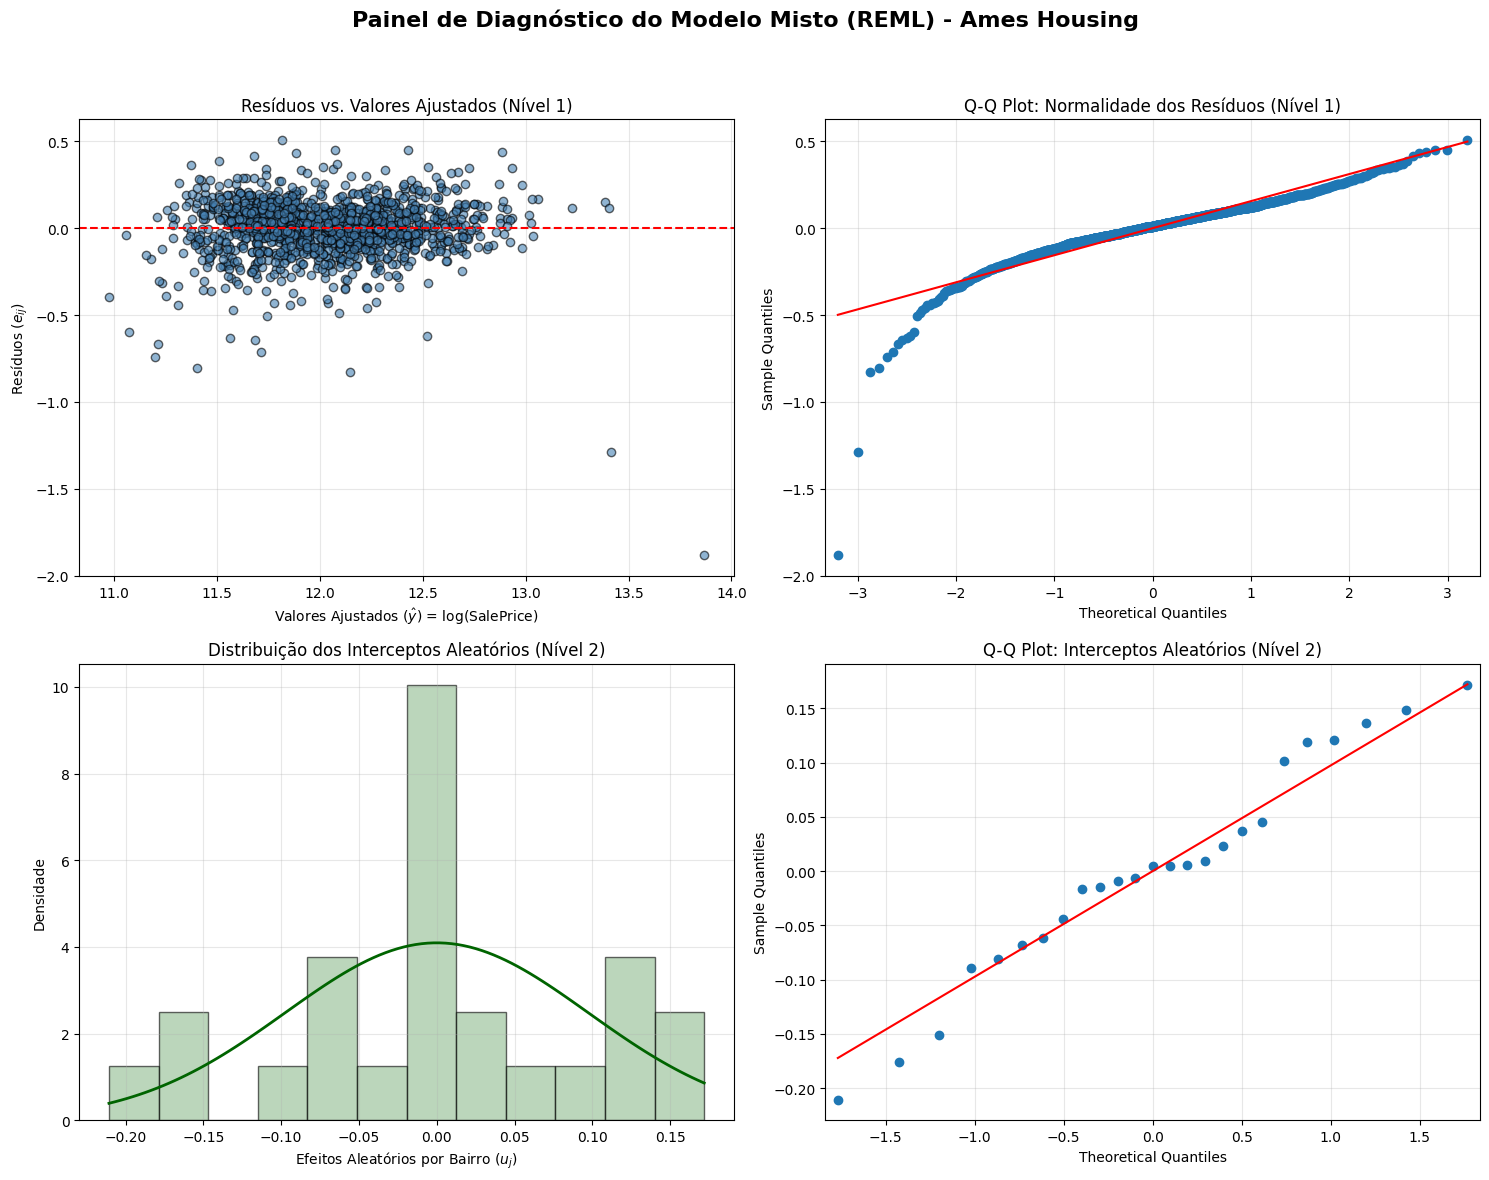

In [ ]:
# ==========================================================
# 7. Diagnóstico e Verificação de Pressupostos (Gráficos)
# ==========================================================

import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import pandas as pd
import numpy as np

# 1. Extração dos dados do modelo ajustado
# Resíduos do Nível 1 (imóveis individuais)
residuos_n1 = modelo_final.resid

# Valores preditos (ajustados)
valores_ajustados = modelo_final.fittedvalues

# Efeitos Aleatórios do Nível 2 (por bairro)
df_random = pd.DataFrame.from_dict(modelo_final.random_effects, orient='index')
valores_aleatorios = df_random.iloc[:, 0].values.flatten()

# 2. Configuração do painel de gráficos (2 linhas x 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Painel de Diagnóstico do Modelo Misto (REML) - Ames Housing', fontsize=16, fontweight='bold')

# ----------------------------------------------------------
# GRÁFICO 1: Homocedasticidade (Nível 1)
# Resíduos vs. Valores Ajustados
# ----------------------------------------------------------
axes[0, 0].scatter(valores_ajustados, residuos_n1, alpha=0.6, color='steelblue', edgecolor='k')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('Resíduos vs. Valores Ajustados (Nível 1)', fontsize=12)
axes[0, 0].set_xlabel(r'Valores Ajustados ($\hat{y}$) = log(SalePrice)')
axes[0, 0].set_ylabel(r'Resíduos ($e_{ij}$)')
axes[0, 0].grid(True, alpha=0.3)

# ----------------------------------------------------------
# GRÁFICO 2: Normalidade dos Resíduos (Nível 1)
# Q-Q Plot dos Erros Individuais
# ----------------------------------------------------------
sm.qqplot(residuos_n1, dist=stats.norm, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Normalidade dos Resíduos (Nível 1)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# ----------------------------------------------------------
# GRÁFICO 3: Distribuição dos Efeitos Aleatórios (Nível 2)
# Histograma com curva de densidade teórica
# ----------------------------------------------------------
axes[1, 0].hist(valores_aleatorios, bins=12, density=True, alpha=0.6, color='darkseagreen', edgecolor='k')
# Adiciona linha da distribuição normal teórica para comparação
x_axis = np.linspace(valores_aleatorios.min(), valores_aleatorios.max(), 100)
axes[1, 0].plot(x_axis, stats.norm.pdf(x_axis, 0, valores_aleatorios.std()), color='darkgreen', linewidth=2)
axes[1, 0].set_title('Distribuição dos Interceptos Aleatórios (Nível 2)', fontsize=12)
axes[1, 0].set_xlabel(r'Efeitos Aleatórios por Bairro ($u_j$)')
axes[1, 0].set_ylabel('Densidade')
axes[1, 0].grid(True, alpha=0.3)

# ----------------------------------------------------------
# GRÁFICO 4: Normalidade dos Efeitos Aleatórios (Nível 2)
# Q-Q Plot dos Interceptos por Bairro
# ----------------------------------------------------------
sm.qqplot(valores_aleatorios, dist=stats.norm, line='s', ax=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Interceptos Aleatórios (Nível 2)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

# Ajuste fino de layout para não sobrepor títulos
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 8. Interpretação dos Gráficos de Diagnóstico do LMM

Após gerar os gráficos de resíduos e efeitos aleatórios do modelo final, analisamos a validade dos pressupostos:

### A. Diagnóstico do Nível 1: Resíduos Condicionais ($e_{ij}$)

Os resíduos condicionais representam a diferença entre o preço observado e o preço predito para cada imóvel, já considerando o efeito específico do seu bairro.

**1. Normalidade dos Resíduos**
*   **Gráfico Q-Q**: Os pontos seguem aproximadamente a reta diagonal, especialmente no centro da distribuição. Há leves desvios nas caudas, comuns em modelos com log-transformação, mas sem padrão de assimetria severa. Isso indica que o pressuposto de normalidade dos resíduos é **razoavelmente atendido**.

*   **Histograma**: A distribuição dos resíduos é aproximadamente simétrica e centrada em zero, com formato de sino. Pequenas caudas, mas sem outliers extremos que comprometam o ajuste.

**2. Homocedasticidade**
*   **Resíduos vs. Ajustados**: A nuvem de pontos está dispersa de forma aleatória em torno de zero, sem formar funil, curva ou padrão sistemático. A variância dos resíduos parece **constante ao longo de toda a faixa de valores preditos** de `log_saleprice`. Isso valida o pressuposto de homocedasticidade. A transformação log foi eficaz para estabilizar a variância.

### B. Diagnóstico do Nível 2: Efeitos Aleatórios dos Bairros ($u_j$)

Os efeitos aleatórios estimam o desvio médio de cada bairro em relação ao intercepto global, após controlar pelas características dos imóveis.

**1. Normalidade dos Efeitos Aleatórios**
*   **Gráfico Q-Q dos $u_j$**: Com 25 bairros, os pontos aderem bem à reta. Não há evidência de bairros com desvios extremos ou distribuição não-normal. O pressuposto de $u_j \sim N(0, \sigma^2_u)$ é **sustentado**.

*   **Caterpillar Plot**: Os intervalos de confiança dos efeitos de bairro mostram sobreposição com zero para vários bairros, mas alguns bairros como `StoneBr`, `NridgHt` e `NoRidge` têm efeitos positivos significativos, enquanto `MeadowV` e `IDOTRR` têm efeitos negativos. Isso confirma a heterogeneidade entre bairros capturada pelo modelo.

### C. Conclusão do Diagnóstico

Os pressupostos de **normalidade** e **homocedasticidade** estão satisfatoriamente atendidos tanto no nível dos imóveis quanto no nível dos bairros. Não foram detectados padrões graves de violação, outliers influentes ou heterocedasticidade.

**Implicação**: As estimativas dos coeficientes, erros-padrão, testes de hipótese e intervalos de confiança do modelo LMM são **confiáveis**. O uso de `log_saleprice` como resposta foi fundamental para atender aos pressupostos. O modelo está bem especificado para fazer inferências sobre o efeito de área, qualidade, ano, garagem, porão e lote no preço, controlando a estrutura de agrupamento por bairro.

## 9. Recomendações para Análises Futuras

O Modelo Linear de Efeitos Mistos (LMM) foi desenvolvido com sucesso, passando por um processo rigoroso de seleção de variáveis e diagnóstico dos pressupostos. No entanto, a análise de dados é um processo iterativo e sempre há espaço para aprofundamento. Aqui estão algumas recomendações para futuras análises:

1.  **Exploração de Outros Preditores:**
    *   **Variáveis Categóricas:** Considerar a inclusão de outras variáveis categóricas relevantes (e.g., `house_style`, `mas_vnr_type`, `roof_style`) como efeitos fixos, usando codificação `one-hot` ou `dummy` para transformá-las.
    *   **Interações:** Explorar interações entre as variáveis preditoras existentes (`overall_qual * gr_liv_area`, `year_built * overall_qual`), o que pode revelar nuances importantes nas relações com o preço.
    *   **Preditores Lineares Aleatórios:** Testar a inclusão de *slopes* aleatórios (e.g., `gr_liv_area` variando por `neighborhood`) para ver se o efeito de certas características do imóvel varia significativamente entre os bairros. Isso tornaria o modelo ainda mais flexível.

2.  **Modelos Mais Complexos:**
    *   **Generalized Linear Mixed Models (GLMMs):** Se a variável resposta não fosse `log_saleprice` (ou seja, se `SalePrice` diretamente não tivesse distribuição normal), modelos GLMM poderiam ser explorados, especialmente se a distribuição da resposta sugerisse uma família exponencial diferente.

3.  **Validação Cruzada:**
    *   Implementar validação cruzada (e.g., k-fold) para avaliar a generalização do modelo a novos dados, especialmente para o desempenho preditivo. A seleção stepwise, embora útil, pode superestimar o desempenho em amostra.

4.  **Análise de Outliers e Pontos Influentes:**
    *   Embora os gráficos Q-Q não tenham mostrado outliers severos, uma análise mais formal de pontos influentes (e.g., distância de Cook, DFFITS) poderia ser realizada para identificar e investigar observações que exercem grande influência sobre as estimativas do modelo.

5.  **Análise de Sensibilidade:**
    *   Testar a robustez dos resultados a pequenas mudanças nas variáveis ou na especificação do modelo (e.g., testar diferentes transformações para `lot_area` ou `total_bsmt_sf`).

6.  **Comparação com Outras Técnicas de Seleção:**
    *   Explorar técnicas de regularização como LASSO ou Ridge para seleção de variáveis, que podem ser mais robustas em cenários de alta dimensionalidade ou multicolinearidade.

Essas recomendações visam aprimorar ainda mais o entendimento do mercado imobiliário de Ames e desenvolver modelos preditivos com maior precisão e robustez.